## Predicting Irrigation Need

#### Cleaning 

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
sns.set_style("whitegrid")

In [ ]:


train = pd.read_csv(r"D:\FCI\03-Project\06-competitions\02-Predicting Irrigation Need\data\playground-series-s6e4\train.csv")
test = pd.read_csv(r"D:\FCI\03-Project\06-competitions\02-Predicting Irrigation Need\data\playground-series-s6e4\test.csv")
sub = pd.read_csv(r"D:\FCI\03-Project\06-competitions\02-Predicting Irrigation Need\data\playground-series-s6e4\sample_submission.csv")
print(f"Train shape     : {train.shape}")
print(f"Test shape      : {test.shape}")
print(f"Submission shape: {sub.shape}\n")

Train shape     : (630000, 21)
Test shape      : (270000, 20)
Submission shape: (270000, 2)



In [3]:
print("Train columns:\n", train.columns.tolist())
print("\nTarget distribution:")
print(train['Irrigation_Need'].value_counts(normalize=True).round(4) * 100)

Train columns:
 ['id', 'Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need']

Target distribution:
Irrigation_Need
Low       58.72
Medium    37.95
High       3.33
Name: proportion, dtype: float64


In [4]:
# Basic info
print("\nTrain info:")
train.info()


Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  obje

In [5]:
display(train.head())

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [6]:
print(f"Train duplicates : {train.duplicated().sum():,}")
print(f"Test duplicates  : {test.duplicated().sum():,}")

Train duplicates : 0
Test duplicates  : 0


In [7]:
target_col = 'Irrigation_Need'
id_col = 'id' if 'id' in train.columns else None

num_cols = train.select_dtypes(include=['int64', 'float64']).columns.tolist()
if id_col: num_cols = [c for c in num_cols if c != id_col]
if target_col in num_cols: num_cols.remove(target_col)

cat_cols = train.select_dtypes(include=['object', 'category']).columns.tolist()
if target_col in cat_cols: cat_cols.remove(target_col)
print(f"ID column       : {id_col}")
print(f"Target          : {target_col}")
print(f"Numerical cols  : {len(num_cols)} → {num_cols}")
print(f"Categorical cols: {len(cat_cols)} → {cat_cols}")

ID column       : id
Target          : Irrigation_Need
Numerical cols  : 11 → ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
Categorical cols: 8 → ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']


In [8]:
display(train.describe())

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


C:\Users\SH\AppData\Local\Temp\ipykernel_27708\3405423555.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=train, x='Irrigation_Need', order=['Low', 'Medium', 'High'], palette='viridis')


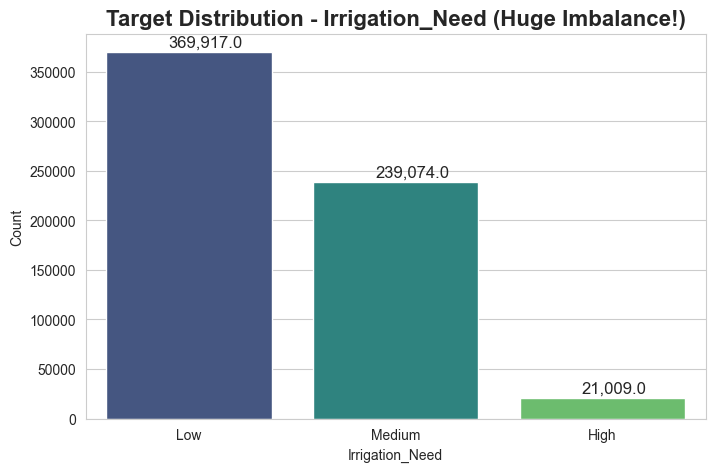

Target percentages:
Irrigation_Need
Low       58.72
Medium    37.95
High       3.33
Name: proportion, dtype: float64


In [9]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=train, x='Irrigation_Need', order=['Low', 'Medium', 'High'], palette='viridis')
plt.title('Target Distribution - Irrigation_Need (Huge Imbalance!)', fontsize=16, fontweight='bold')
plt.ylabel('Count')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x()+0.3, p.get_height()+5000), fontsize=12)
plt.show()

print("Target percentages:")
print(train['Irrigation_Need'].value_counts(normalize=True).round(4)*100)

C:\Users\SH\AppData\Local\Temp\ipykernel_27708\285352929.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='Irrigation_Need', y=col, ax=axes[i], palette='viridis', order=['Low','Medium','High'])
C:\Users\SH\AppData\Local\Temp\ipykernel_27708\285352929.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='Irrigation_Need', y=col, ax=axes[i], palette='viridis', order=['Low','Medium','High'])
C:\Users\SH\AppData\Local\Temp\ipykernel_27708\285352929.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train, x='I

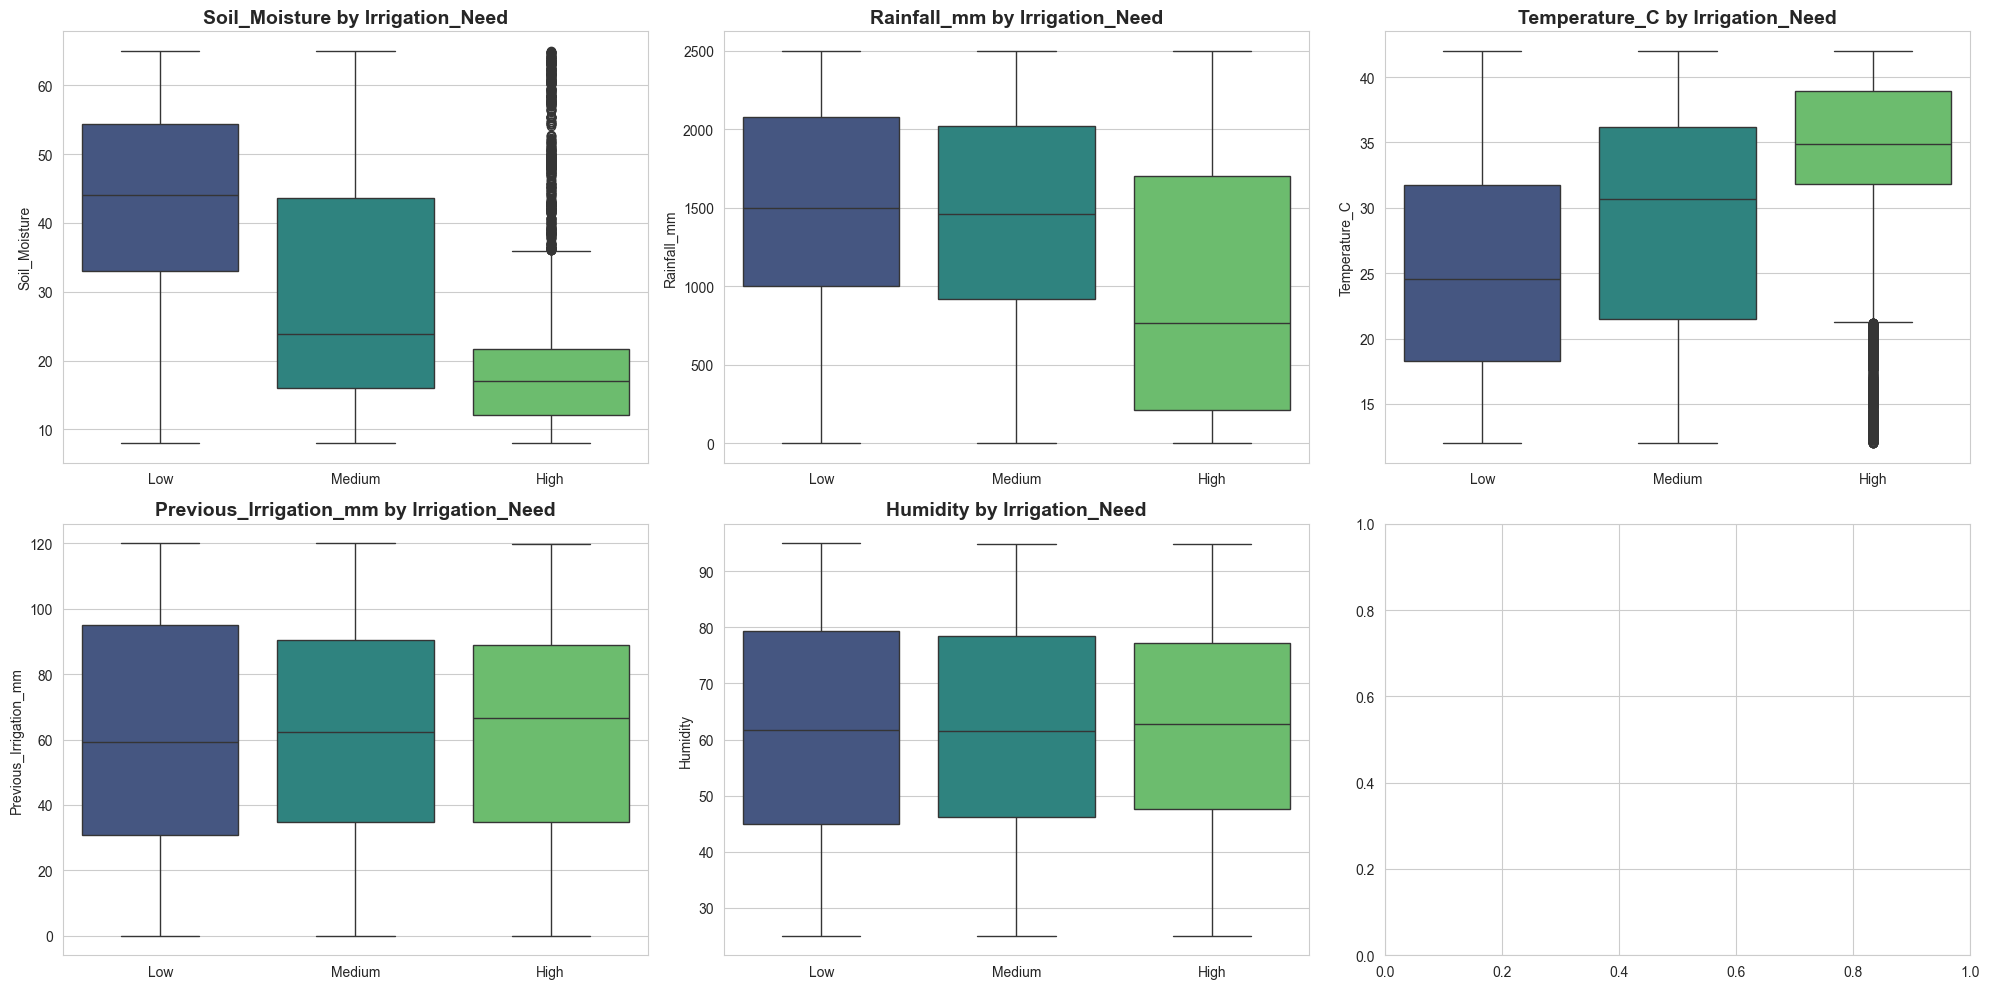

In [10]:
key_num = ['Soil_Moisture', 'Rainfall_mm', 'Temperature_C', 'Previous_Irrigation_mm', 'Humidity']

fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.ravel()

for i, col in enumerate(key_num):
    sns.boxplot(data=train, x='Irrigation_Need', y=col, ax=axes[i], palette='viridis', order=['Low','Medium','High'])
    axes[i].set_title(f'{col} by Irrigation_Need', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')
plt.tight_layout()
plt.show()

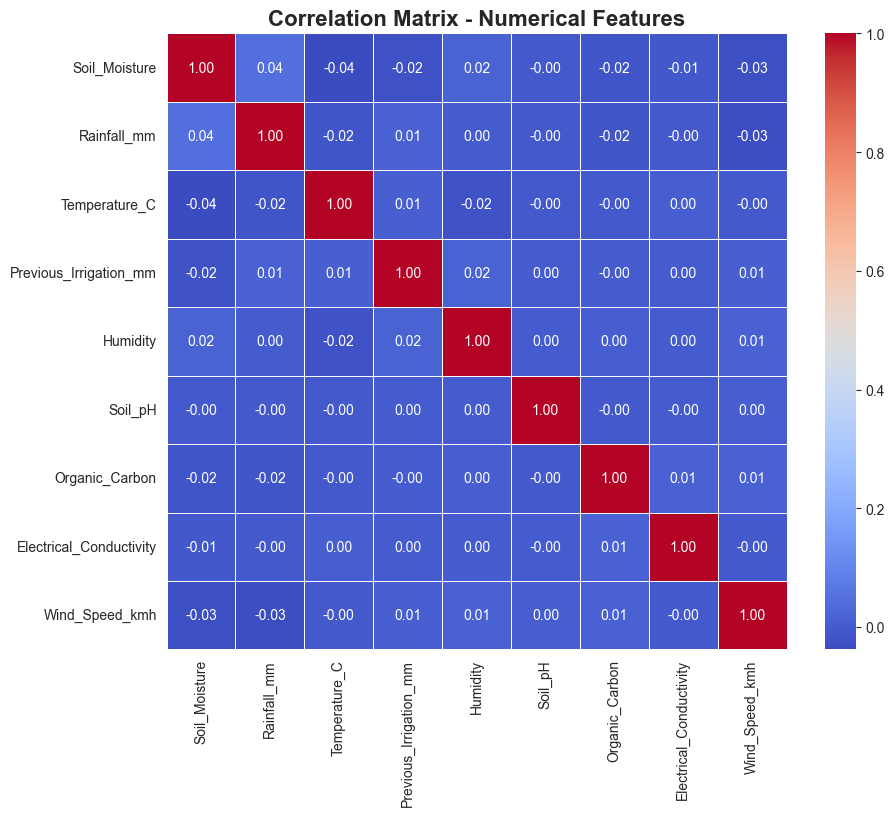

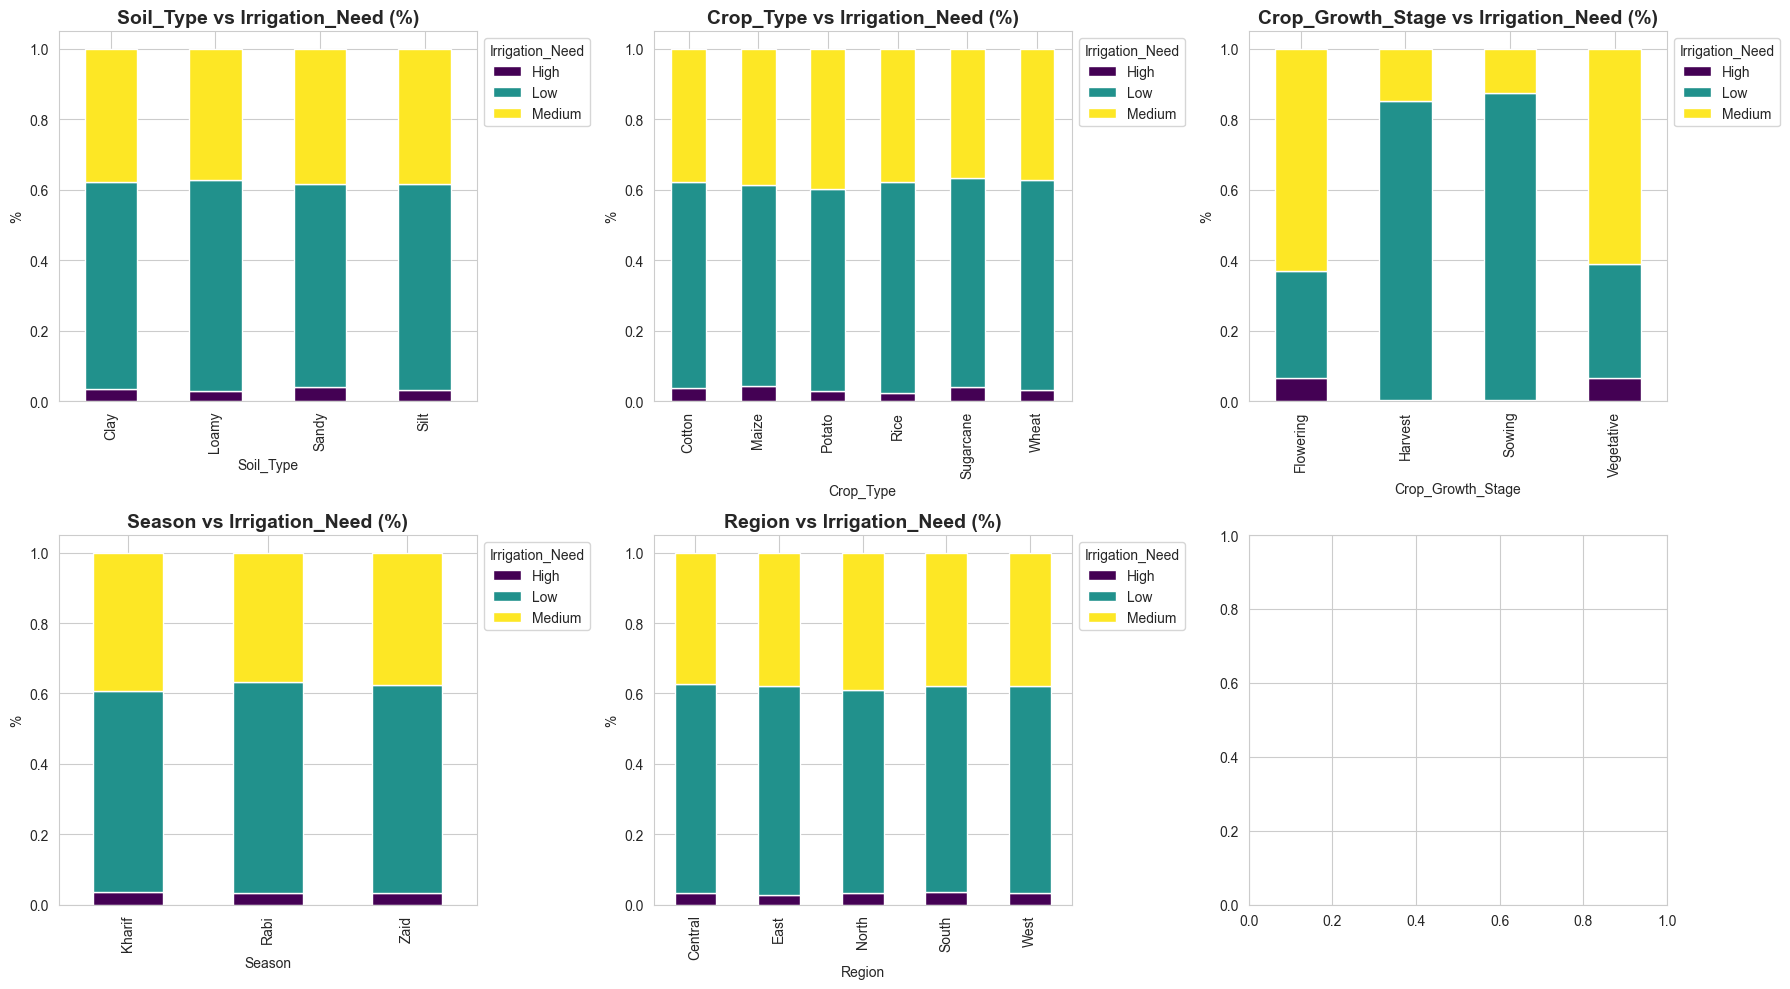

In [11]:
plt.figure(figsize=(10, 8))
corr = train[key_num + ['Soil_pH','Organic_Carbon','Electrical_Conductivity','Wind_Speed_kmh']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix - Numerical Features', fontsize=16, fontweight='bold')
plt.show()

cat_to_check = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Region']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for i, col in enumerate(cat_to_check):
    pd.crosstab(train[col], train['Irrigation_Need'], normalize='index').plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis')
    axes[i].set_title(f'{col} vs Irrigation_Need (%)', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('%')
    axes[i].legend(title='Irrigation_Need', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

### DOMAIN FEATURE ENGINEERING + BASELINE LGBM

#### 1. FEATURE ENGINEERING

In [12]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score

def create_domain_features(df):
    df = df.copy()
    # Thresholds from EDA boxplots
    df['Soil_Moisture_Low']     = (df['Soil_Moisture'] < 25).astype(int)
    df['Soil_Moisture_Med']     = ((df['Soil_Moisture'] >= 25) & (df['Soil_Moisture'] < 40)).astype(int)
    df['Rainfall_Low']          = (df['Rainfall_mm'] < 1000).astype(int)
    df['Temp_High']             = (df['Temperature_C'] > 30).astype(int)
    df['High_Temp_Low_Rain']    = ((df['Temperature_C'] > 30) & (df['Rainfall_mm'] < 1000)).astype(int)
    
    # Physics / interaction features
    df['Soil_Moisture_x_Temp']      = df['Soil_Moisture'] * df['Temperature_C']
    df['Soil_Moisture_x_Rain']      = df['Soil_Moisture'] * df['Rainfall_mm']
    df['Prev_Irrigation_Deficit']   = df['Previous_Irrigation_mm'] - df['Soil_Moisture'] * 2
    
    return df

train_fe = create_domain_features(train)
test_fe  = create_domain_features(test)

#### 2. FIX CATEGORICAL FEATURES

In [13]:
cat_features = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season',
                'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']

for col in cat_features:
    if col in train_fe.columns:
        train_fe[col] = train_fe[col].astype('category')
        test_fe[col]  = test_fe[col].astype('category')


#### 3. ENCODE TARGET TO INTEGERS (THE NEW FIX)

In [14]:
target_col = 'Irrigation_Need'
id_col = 'id'

# Manual mapping (most reproducible)
label_map = {'Low': 0, 'Medium': 1, 'High': 2}
y_encoded = train_fe[target_col].map(label_map)

print(y_encoded.value_counts().sort_index())

X = train_fe.drop(columns=[id_col, target_col])
y = y_encoded   

Irrigation_Need
0    369917
1    239074
2     21009
Name: count, dtype: int64


#### 4. STRATIFIED CV + BASELINE TRAINING

Splitting data into train and validation...
Train shape: (535500, 27) | Validation shape: (94500, 27)
Training until validation scores don't improve for 100 rounds
[100]	valid_0's multi_logloss: 0.0615248
[200]	valid_0's multi_logloss: 0.0579001
[300]	valid_0's multi_logloss: 0.0569368
[400]	valid_0's multi_logloss: 0.0567677
[500]	valid_0's multi_logloss: 0.0566225
Early stopping, best iteration is:
[476]	valid_0's multi_logloss: 0.0566149

Validation Balanced Accuracy: 0.96142


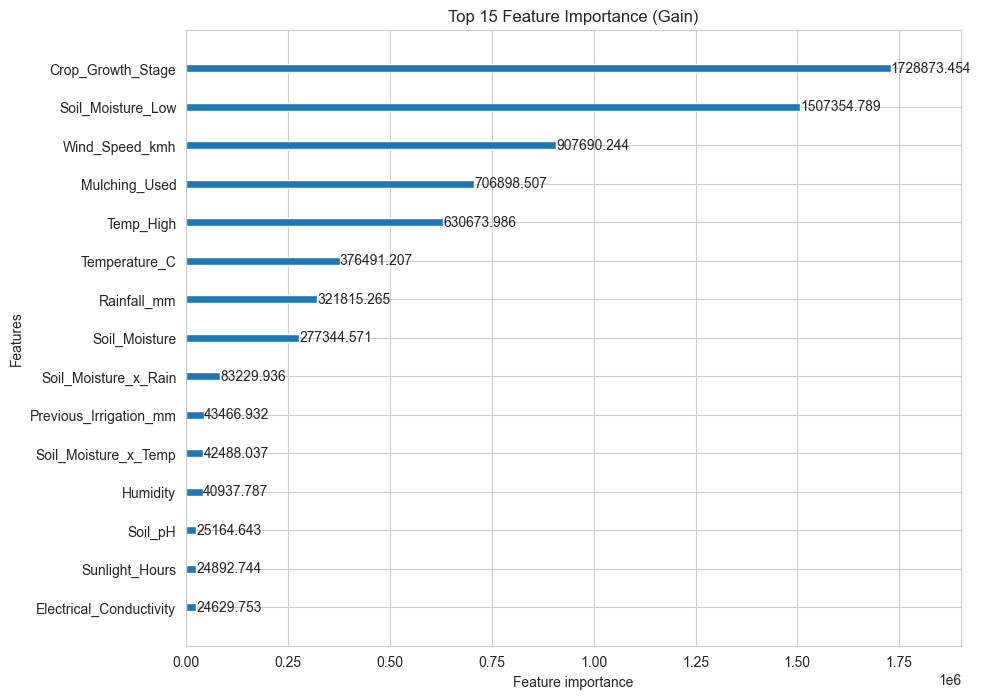

In [15]:
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import balanced_accuracy_score
import matplotlib.pyplot as plt

params = {
    'objective': 'multiclass',
    'metric': 'multi_logloss',
    'num_class': 3,
    'learning_rate': 0.05,
    'num_leaves': 64,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42,
    'class_weight': 'balanced',
}
# ==================== HOLD-OUT VALIDATION ====================
print("Splitting data into train and validation...")

X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.15,          
    stratify=y, 
    random_state=42
)

print(f"Train shape: {X_train.shape} | Validation shape: {X_val.shape}")

# Prepare LightGBM datasets
lgb_train = lgb.Dataset(X_train, y_train, categorical_feature=cat_features)
lgb_val   = lgb.Dataset(X_val, y_val, reference=lgb_train, categorical_feature=cat_features)


model = lgb.train(
    params,
    lgb_train,
    num_boost_round=3000,                    # high number is fine because of early stopping
    valid_sets=[lgb_val],
    callbacks=[
        lgb.early_stopping(100, verbose=True),  
        lgb.log_evaluation(100)                 
    ]
)

# Predict on validation
oof_pred = model.predict(X_val)
y_val_pred = np.argmax(oof_pred, axis=1)
score = balanced_accuracy_score(y_val, y_val_pred)

print(f"\nValidation Balanced Accuracy: {score:.5f}")

# Feature Importance
lgb.plot_importance(model, max_num_features=15, importance_type='gain', figsize=(10, 8))
plt.title('Top 15 Feature Importance (Gain)')
plt.show()

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

        High     0.9693    0.9130    0.9403      3151
         Low     0.9860    0.9956    0.9908     55488
      Medium     0.9854    0.9756    0.9805     35861

    accuracy                         0.9853     94500
   macro avg     0.9803    0.9614    0.9705     94500
weighted avg     0.9852    0.9853    0.9852     94500



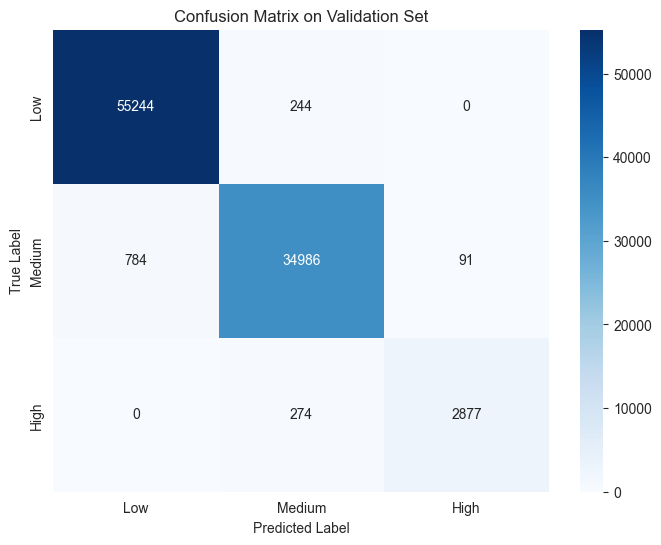


Per-class Recall:
Low    : 0.9956
Medium : 0.9756
High   : 0.9130


In [16]:
# ====================== DETAILED MODEL ANALYSIS ======================
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# Predict on validation set
val_pred_proba = model.predict(X_val)
val_pred = np.argmax(val_pred_proba, axis=1)

# Map back to original labels
label_map_inverse = {0: 'Low', 1: 'Medium', 2: 'High'}
y_val_labels = y_val.map(label_map_inverse)
val_pred_labels = pd.Series(val_pred).map(label_map_inverse)

print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_val_labels, val_pred_labels, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_val_labels, val_pred_labels, labels=['Low', 'Medium', 'High'])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low', 'Medium', 'High'], 
            yticklabels=['Low', 'Medium', 'High'])
plt.title('Confusion Matrix on Validation Set')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Per-class recall (most important for imbalanced data)
print("\nPer-class Recall:")
for i, cls in enumerate(['Low', 'Medium', 'High']):
    recall = cm[i, i] / cm[i].sum()
    print(f"{cls:6} : {recall:.4f}")

--- Optimization for 'High' Class ---
Best Threshold for 95.0% Recall: 0.0692
Precision at this threshold: 0.8616


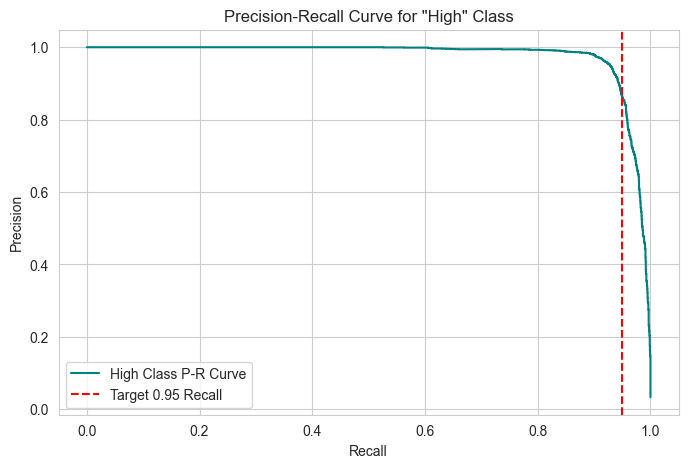

In [17]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# 1. Focus on the 'High' class (Index 2 in your label map)
high_class_idx = 2
y_val_binary_high = (y_val == high_class_idx).astype(int)
high_probs = val_pred_proba[:, high_class_idx]

precision, recall, thresholds = precision_recall_curve(y_val_binary_high, high_probs)

# 2. Find the threshold that gives us at least 95% recall
target_recall = 0.95
idx = np.where(recall >= target_recall)[0][-1]
best_threshold = thresholds[idx]

print(f"--- Optimization for 'High' Class ---")
print(f"Best Threshold for {target_recall*100}% Recall: {best_threshold:.4f}")
print(f"Precision at this threshold: {precision[idx]:.4f}")

# 3. Visualize the Trade-off
plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label='High Class P-R Curve', color='teal')
plt.axvline(x=target_recall, color='red', linestyle='--', label=f'Target {target_recall} Recall')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for "High" Class')
plt.legend()
plt.show()

=== NEW CLASSIFICATION REPORT (Optimized) ===
              precision    recall  f1-score   support

        High     0.8616    0.9502    0.9037      3151
         Low     0.9860    0.9956    0.9908     55488
      Medium     0.9885    0.9647    0.9765     35861

    accuracy                         0.9824     94500
   macro avg     0.9454    0.9702    0.9570     94500
weighted avg     0.9828    0.9824    0.9825     94500



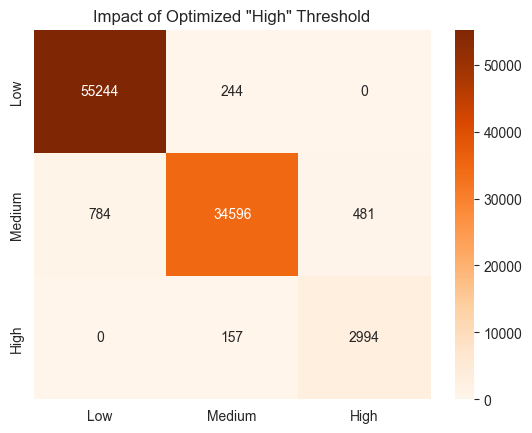

In [18]:
def custom_predict(proba, threshold_high=0.0692):
    """
    Applies a priority threshold for the 'High' class (Index 2).
    If P(High) > threshold, predict 'High'. 
    Otherwise, pick the best between 'Low' and 'Medium'.
    """
    # Initialize with standard argmax
    final_preds = np.argmax(proba, axis=1)
    
    # Identify where 'High' (Index 2) meets our new sensitivity requirement
    high_mask = proba[:, 2] >= threshold_high
    final_preds[high_mask] = 2
    
    return final_preds

# 1. Generate new labels
val_pred_custom = custom_predict(val_pred_proba)
val_pred_labels_custom = pd.Series(val_pred_custom).map(label_map_inverse)

# 2. Re-run your report to see the TOTAL impact
print("=== NEW CLASSIFICATION REPORT (Optimized) ===")
print(classification_report(y_val_labels, val_pred_labels_custom, digits=4))

# 3. New Confusion Matrix to see the 'Leakage'
cm_new = confusion_matrix(y_val_labels, val_pred_labels_custom, labels=['Low', 'Medium', 'High'])
sns.heatmap(cm_new, annot=True, fmt='d', cmap='Oranges', xticklabels=['Low', 'Medium', 'High'], yticklabels=['Low', 'Medium', 'High'])
plt.title('Impact of Optimized "High" Threshold')
plt.show()

In [19]:
from sklearn.model_selection import StratifiedKFold

def verify_threshold_stability(X, y, target_recall=0.95, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits)
    thresholds = []
    
    print(f"Verifying Threshold for {target_recall} Recall")
    
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        
        y_fold = y.iloc[val_idx]
        
        # Predict probabilities for this slice
        probs_fold = model.predict(X.iloc[val_idx])[:, 2] # Probabilities for 'High'
        
        # Calculate the threshold for this specific fold
        precision_f, recall_f, thresh_f = precision_recall_curve((y_fold == 2).astype(int), probs_fold)
        
        # Find threshold where recall >= 0.95
        idx = np.where(recall_f >= target_recall)[0][-1]
        fold_threshold = thresh_f[idx]
        thresholds.append(fold_threshold)
        
        print(f"Fold {fold+1}: Optimal Threshold = {fold_threshold:.4f}")

    avg_threshold = np.mean(thresholds)
    std_threshold = np.std(thresholds)
    
    print(f"\n Recommended Stable Threshold: {avg_threshold:.4f} (±{std_threshold:.4f})")
    return avg_threshold


#### The Production Wrapper Function

In [20]:
import numpy as np
import pandas as pd

def get_optimized_predictions(model, X, threshold_high=0.0692):
    """
    Predicts labels using a custom threshold for the 'High' class.
    
    Parameters:
    - model: The trained model object.
    - X: The features (DataFrame or array).
    - threshold_high: The probability threshold for the 'High' class.
    
    Returns:
    - final_labels: A pandas Series with ['Low', 'Medium', 'High']
    """
    # 1. Get raw probabilities
    # Assuming model.predict returns probabilities [P(Low), P(Medium), P(High)]
    proba = model.predict(X)
    
    # 2. Start with the default prediction (highest probability)
    # 0=Low, 1=Medium, 2=High
    preds = np.argmax(proba, axis=1)
    
    # 3. Apply the "High" class priority override
    # If the probability of being 'High' is above our threshold, we force it to 2
    high_probs = proba[:, 2]
    preds[high_probs >= threshold_high] = 2
    
    # 4. Map integers back to strings for readability
    label_map_inverse = {0: 'Low', 1: 'Medium', 2: 'High'}
    final_labels = pd.Series(preds).map(label_map_inverse)
    
    return final_labels

--- Verifying Threshold for 95.0% Recall ---
Fold 1: Threshold = 0.6357
Fold 2: Threshold = 0.6417
Fold 3: Threshold = 0.6310
Fold 4: Threshold = 0.6004
Fold 5: Threshold = 0.6177
Recommended Stable Threshold: 0.6253 (±0.0147)

              precision    recall  f1-score   support

        High     0.9693    0.9130    0.9403      3151
         Low     0.9860    0.9956    0.9908     55488
      Medium     0.9854    0.9756    0.9805     35861

    accuracy                         0.9853     94500
   macro avg     0.9803    0.9614    0.9705     94500
weighted avg     0.9852    0.9853    0.9852     94500



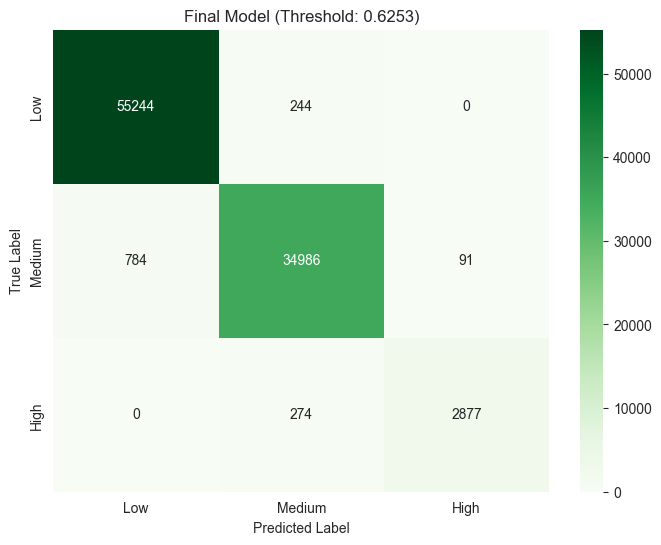

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
from sklearn.model_selection import StratifiedKFold


def get_optimized_predictions(model, X, threshold_high=0.0692):
    """
    Applies a priority threshold for the 'High' class (Index 2).
    """
    # 1. Get raw probabilities
    proba = model.predict(X)
    
    # 2. Standard argmax (default behavior)
    preds = np.argmax(proba, axis=1)
    
    # 3. Apply the High-Class Override
    # Index 2 is 'High'. If P(High) > threshold, we prioritize it.
    high_probs = proba[:, 2]
    preds[high_probs >= threshold_high] = 2
    
    # 4. Map back to strings
    label_map_inverse = {0: 'Low', 1: 'Medium', 2: 'High'}
    return pd.Series(preds).map(label_map_inverse)

def verify_threshold_stability(model, X, y, target_recall=0.95, n_splits=5):
    """
    Checks if the threshold is stable across different data folds.
    Ensures the 0.0692 isn't just 'lucky' for one specific split.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    thresholds = []
    
    print(f"--- Verifying Threshold for {target_recall*100}% Recall ---")
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        # Isolate fold data
        X_fold_val = X.iloc[val_idx]
        y_fold_val = y.iloc[val_idx]
        
        # Get probabilities for 'High' (Index 2)
        probs = model.predict(X_fold_val)[:, 2]
        
        # Calculate P-R Curve for the 'High' class (binary)
        precision, recall, thresholds_fold = precision_recall_curve((y_fold_val == 2).astype(int), probs)
        
        # Find threshold where recall is closest to target
        # Filter for recall >= target_recall, then take the last one
        valid_indices = np.where(recall >= target_recall)[0]
        if len(valid_indices) > 0:
            best_idx = valid_indices[-1]
            # thresholds_fold is 1 element shorter than recall/precision
            fold_threshold = thresholds_fold[min(best_idx, len(thresholds_fold)-1)]
            thresholds.append(fold_threshold)
            print(f"Fold {fold+1}: Threshold = {fold_threshold:.4f}")
    
    avg_threshold = np.mean(thresholds)
    print(f"Recommended Stable Threshold: {avg_threshold:.4f} (±{np.std(thresholds):.4f})\n")
    return avg_threshold


# --- SECTION 2: EXECUTION PIPELINE ---

X_full = pd.concat([X_train, X_val]).reset_index(drop=True)
y_full = pd.concat([y_train, y_val]).reset_index(drop=True)

# 2. Run Stability Check to find the "Production Threshold"
stable_threshold = verify_threshold_stability(model, X_full, y_full, target_recall=0.95)

# 3. Generate Final Optimized Predictions on Validation Set
final_labels = get_optimized_predictions(model, X_val, threshold_high=stable_threshold)

# 4. Final Evaluation
y_val_labels = y_val.map({0: 'Low', 1: 'Medium', 2: 'High'})

print(classification_report(y_val_labels, final_labels, digits=4))

# 5. Confusion Matrix Visualization
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_val_labels, final_labels, labels=['Low', 'Medium', 'High'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Low', 'Medium', 'High'], 
            yticklabels=['Low', 'Medium', 'High'])
plt.title(f'Final Model (Threshold: {stable_threshold:.4f})')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [22]:

# Check what the model expects vs what we have
expected_features = model.feature_name()
current_test_cols = test.columns.tolist()

missing_from_test = [f for f in expected_features if f not in current_test_cols]

print("---  Feature Audit ---")
print(f"Model expects {len(expected_features)} features.")
print(f"Test set currently has {len(current_test_cols)} features.")
print(f"\nMissing Features that must be engineered: \n{missing_from_test}")

# Identify the base numerical columns we have to work with
numerical_bases = test.select_dtypes(include=['number']).columns.tolist()
print(f"\n Available Numerical Bases: \n{numerical_bases}")

---  Feature Audit ---
Model expects 27 features.
Test set currently has 20 features.

Missing Features that must be engineered: 
['Soil_Moisture_Low', 'Soil_Moisture_Med', 'Rainfall_Low', 'Temp_High', 'High_Temp_Low_Rain', 'Soil_Moisture_x_Temp', 'Soil_Moisture_x_Rain', 'Prev_Irrigation_Deficit']

 Available Numerical Bases: 
['id', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']


In [23]:
import numpy as np
import pandas as pd

def create_domain_features_final(df):
    """
    Using your exact EDA-based thresholds and physics interactions.
    """
    df = df.copy()
    # Exact thresholds from your EDA
    df['Soil_Moisture_Low']     = (df['Soil_Moisture'] < 25).astype(int)
    df['Soil_Moisture_Med']     = ((df['Soil_Moisture'] >= 25) & (df['Soil_Moisture'] < 40)).astype(int)
    df['Rainfall_Low']          = (df['Rainfall_mm'] < 1000).astype(int)
    df['Temp_High']             = (df['Temperature_C'] > 30).astype(int)
    df['High_Temp_Low_Rain']    = ((df['Temperature_C'] > 30) & (df['Rainfall_mm'] < 1000)).astype(int)
    
    # Physics / interaction features
    df['Soil_Moisture_x_Temp']      = df['Soil_Moisture'] * df['Temperature_C']
    df['Soil_Moisture_x_Rain']      = df['Soil_Moisture'] * df['Rainfall_mm']
    
    # Your specific deficit formula: Previous - (Moisture * 2)
    df['Prev_Irrigation_Deficit']   = df['Previous_Irrigation_mm'] - (df['Soil_Moisture'] * 2)
    
    return df


def run_final_competition_pipeline(model, train_df, test_df, sub_df, threshold):
    print("--- Applying Exact Domain Features ---")
    X_test = create_domain_features_final(test_df)
    
    print("---  Re-syncing Categorical Metadata ---")
    cat_cols = ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 
                'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region']
    
    for col in cat_cols:
        if col in X_test.columns:
            # Ensuring category codes match training exactly
            train_cats = train_df[col].astype('category').cat.categories
            X_test[col] = pd.Categorical(X_test[col], categories=train_cats)

    # Use the model's internal feature list to set column order
    model_features = model.feature_name()
    X_test = X_test[model_features]
    
    print(f"--- Predicting on {len(X_test)} Test Samples ---")
    test_probs = model.predict(X_test)
    
    # Apply threshold for Balanced Accuracy optimization
    final_preds_idx = np.argmax(test_probs, axis=1)
    final_preds_idx[test_probs[:, 2] >= threshold] = 2
    
    # Map back to labels
    label_map = {0: 'Low', 1: 'Medium', 2: 'High'}
    sub_df['Irrigation_Need'] = [label_map[i] for i in final_preds_idx]
    
    return sub_df




####  EXECUTION

In [24]:
# Using the optimized threshold you found earlier
winning_threshold = 0.0692 

final_sub = run_final_competition_pipeline(model, train, test, sub, winning_threshold)

# Final file naming
filename = f'submission_final_threshold_{str(winning_threshold).replace(".", "")}.csv'
final_sub.to_csv(filename, index=False)

print(f"\nSUBMISSION SAVED: {filename}")
print("\nFinal Class Distribution:")
print(final_sub['Irrigation_Need'].value_counts(normalize=True))

--- Applying Exact Domain Features ---
---  Re-syncing Categorical Metadata ---
--- Predicting on 270000 Test Samples ---

SUBMISSION SAVED: submission_final_threshold_00692.csv

Final Class Distribution:
Irrigation_Need
Low       0.592307
Medium    0.370163
High      0.037530
Name: proportion, dtype: float64


In [1]:
from flask import Flask, render_template, request
import pandas as pd
import numpy as np
import joblib

app = Flask(__name__)

# Load Model and Category Metadata
model = joblib.load('model.pkl')
categories_map = joblib.load('categories_map.pkl')

def apply_feature_engineering(df):
    """Your exact Domain Features from the Notebook"""
    df = df.copy()
    df['Soil_Moisture_Low'] = (df['Soil_Moisture'] < 25).astype(int)
    df['Soil_Moisture_Med'] = ((df['Soil_Moisture'] >= 25) & (df['Soil_Moisture'] < 40)).astype(int)
    df['Rainfall_Low'] = (df['Rainfall_mm'] < 1000).astype(int)
    df['Temp_High'] = (df['Temperature_C'] > 30).astype(int)
    df['High_Temp_Low_Rain'] = ((df['Temperature_C'] > 30) & (df['Rainfall_mm'] < 1000)).astype(int)
    df['Soil_Moisture_x_Temp'] = df['Soil_Moisture'] * df['Temperature_C']
    df['Soil_Moisture_x_Rain'] = df['Soil_Moisture'] * df['Rainfall_mm']
    df['Prev_Irrigation_Deficit'] = df['Previous_Irrigation_mm'] - (df['Soil_Moisture'] * 2)
    
    # Sync Categorical data
    for col, categories in categories_map.items():
        df[col] = pd.Categorical(df[col], categories=categories)
    return df[model.feature_name()]

@app.route('/')
def home():
    stats = {'train_size': "630,000", 'test_size': "270,000", 'missing': "0"}
    return render_template('index.html', stats=stats, categories=categories_map)

@app.route('/predict', methods=['POST'])
def predict():
    # Collect form data
    raw_data = request.form.to_dict()
    # Convert numeric strings to floats
    numeric_cols = ['Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 
                    'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 
                    'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm']
    for col in numeric_cols:
        raw_data[col] = [float(raw_data[col])]
    
    df = pd.DataFrame(raw_data)
    processed_df = apply_feature_engineering(df)
    
    # Prediction with your 0.0692 threshold
    probs = model.predict(processed_df)
    prediction_idx = np.argmax(probs, axis=1)[0]
    if probs[0, 2] >= 0.0692:
        prediction_idx = 2
        
    label_map = {0: 'Low', 1: 'Medium', 2: 'High'}
    result = label_map[prediction_idx]
    
    return render_template('index.html', prediction=result, categories=categories_map)

if __name__ == '__main__':
    # use_reloader=False prevents the SystemExit error on some machines
    app.run(debug=True, port=5000, use_reloader=False)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
127.0.0.1 - - [31/Aug/2026 22:32:02] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [31/Aug/2026 22:32:03] "GET /static/importance.png HTTP/1.1" 200 -
127.0.0.1 - - [31/Aug/2026 22:32:03] "GET /static/distribution.png HTTP/1.1" 200 -
127.0.0.1 - - [31/Aug/2026 22:32:03] "GET /favicon.ico HTTP/1.1" 404 -
